## MODEL DEVELOPMENT

In [1]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.stats import gaussian_kde
import sys

BASE          = Path("/share/home/e2406751/Superresolution-TIR")
PATCHES_DIR   = BASE / "data/processed/patches"
STATS_PATH    = PATCHES_DIR / "stats.json"
METADATA_PATH = PATCHES_DIR / "metadata.json"
sys.path.insert(0, str(BASE))

with open(STATS_PATH) as f:
    stats_data = json.load(f)

HR_MEAN    = stats_data["hr"]["mean"]
HR_STD     = stats_data["hr"]["std"]
LR_MEAN    = stats_data["lr"]["mean"]
LR_STD     = stats_data["lr"]["std"]
DATA_RANGE = stats_data["hr_data_range"]
DATA_MIN   = stats_data["hr_percentiles"]["p1"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [6]:
import importlib
import scripts.models.realesrgan as realesrgan

importlib.reload(realesrgan)

from scripts.models.realesrgan import RealESRGANModule

MODEL_LABEL = "RealESRGAN + SPADE + physics loss + GAN"  
MODEL_PATH  = str(BASE / "checkpoints/dev_gan/realesrgan_river_eval_epoch=58_val_water_mae=0.0000.ckpt")

model = RealESRGANModule.load_from_checkpoint(MODEL_PATH, strict=True).to(device).eval()

# checkpoints/dev_gan/exp1.1_baseline_epoch=33_val_water_mae=0.0000.ckpt  #baseline* lambdas at 1.0
# checkpoints/dev_gan/realesrgan_river_eval_epoch=30_val_water_mae=0.0000.ckpt #wvsnw sweep
# checkpoints/dev_gan/realesrgan_river_eval_epoch=30_val_water_mae=0.0000-v1.ckpt #grad+adv sweep
# checkpoints/dev_gan/realesrgan_river_eval_epoch=58_val_water_mae=0.0000.ckpt # percep sweep

[INFO] generator loaded 702 params
[INFO] discriminator loaded 28 params


In [3]:
from scripts.utils.dataset import SRDataset

val_ds = SRDataset(
    split="val",
    patches_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    use_aux=True,
    use_water_mask=True,                
    aux_dir=str(PATCHES_DIR / "val" / "AUX"),
    transform=None,
)

print(f"val set size: {len(val_ds)} samples")

val set size: 36 samples


In [4]:
np.random.seed(42)
N_SAMPLES   = 5
vis_indices = np.random.choice(len(val_ds), N_SAMPLES, replace=False)
vis_samples = [val_ds[i] for i in vis_indices]
print(f"\nSelected tiles for viz: {[s['fname'] for s in vis_samples]}")


Selected tiles for viz: ['PDR_2023_b2_r2816_c1024.npy', 'DZM_2014_b2_r2816_c0.npy', 'PDR_2014_b1_r1024_c256.npy', 'PDR_2023_b2_r2048_c512.npy', 'DZM_2019_b1_r1280_c0.npy']


In [7]:
def prep_sample(sample):
    hr_mask = sample["hr_mask"].squeeze().numpy()
    lr_64   = sample["lr"][0].numpy() * LR_STD + LR_MEAN
    lr_256  = np.repeat(np.repeat(lr_64, 4, axis=0), 4, axis=1)
    lr_np   = np.where(hr_mask > 0.5, lr_256, np.nan)
    hr_np   = sample["hr"][0].numpy() * HR_STD + HR_MEAN
    hr_np   = np.where(hr_mask > 0.5, hr_np, np.nan)
    valid   = hr_np[hr_mask > 0.5]
    vmin    = np.nanpercentile(valid, 1)
    vmax    = np.nanpercentile(valid, 99)
    return lr_np, hr_np, hr_mask, vmin, vmax


# def run_inference(sample):
#     """Prepare full multi-scale batch for the new model"""
#     batch = {
#         "lr": sample["lr"].unsqueeze(0).to(device),           # [1, 1, 64, 64]
#         "aux_lr": sample["aux_lr"].unsqueeze(0).to(device),   # [1, 20, 64, 64]
#         "aux_mid": sample["aux_mid"].unsqueeze(0).to(device), # [1, 20, 128, 128]
#         "aux_hr": sample["aux_hr"].unsqueeze(0).to(device),   # [1, 20, 256, 256]
#         "lr_time": sample["lr_time"].unsqueeze(0).to(device),   # [1, 1, 64, 64]
#         "time_gap_hours": sample["time_gap_hours"].unsqueeze(0).to(device), # [1, 1]
#         "date_gap_days": sample["date_gap_days"].unsqueeze(0).to(device),     # [1, 1]
#     }
    
#     with torch.no_grad():
#         sr = model(batch)                                      # [1, 1, 256, 256]
        
#     sr_celsius = (sr[:, 0] * HR_STD + HR_MEAN).squeeze().cpu().numpy()
#     return sr_celsius
def run_inference(model_obj, sample):
    """Prepares full multi-scale batch for the network forward pass"""
    batch = {
        "lr": sample["lr"].unsqueeze(0).to(device),
        "aux_lr": sample["aux_lr"].unsqueeze(0).to(device),
        "aux_mid": sample["aux_mid"].unsqueeze(0).to(device),
        "aux_hr": sample["aux_hr"].unsqueeze(0).to(device),
        "lr_time": sample["lr_time"].unsqueeze(0).to(device),
        "time_gap_hours": sample["time_gap_hours"].unsqueeze(0).to(device),
        "date_gap_days": sample["date_gap_days"].unsqueeze(0).to(device),
    }
    with torch.no_grad():
        sr = model_obj(batch)
    return (sr[:, 0] * HR_STD + HR_MEAN).squeeze().cpu().numpy()


### Input startegy

In [7]:
from scripts.models.realesrgan import RealESRGANModule
 
CKPT_PATH          = BASE / "checkpoints/dev_gan/02_dir_full_epoch=86_val_full_psnr=16.5517.ckpt"

# checkpoints/dev_gan/01_proj_frozen_epoch=90_val_full_psnr=14.0340.ckpt  # projection - frozen
# checkpoints/dev_gan/01_dir_frozen_epoch=21_val_full_psnr=13.8303.ckpt   # direct - frozen
# checkpoints/dev_gan/02_dir_full_epoch=86_val_full_psnr=16.5517.ckpt  # direct - full retrain
# checkpoints/dev_gan/02_proj_full_epoch=91_val_full_psnr=16.5701.ckpt  # projection - full retrain

ADAPTATION_STRATEGY = "direct"   # ← change to "direct" for direct experiment
 
sample_0  = val_ds[0]
aux_chans = sample_0["aux"].shape[0]
print(f"AUX channels: {aux_chans}")
 
model = RealESRGANModule.load_from_checkpoint(
    checkpoint_path     = str(CKPT_PATH),
    adaptation_strategy = ADAPTATION_STRATEGY,
    aux_chans           = aux_chans,
    hr_mean             = HR_MEAN,
    hr_std              = HR_STD,
    data_range          = DATA_RANGE,
    data_min            = DATA_MIN,
    map_location        = device,
)
model = model.to(device).eval()
print(f"[INFO] Model loaded: RealESRGAN {ADAPTATION_STRATEGY}")


AUX channels: 20


[INFO] conv_first expanded 3 → 21 (pretrained_mean)
[INFO] Loading RealESRGAN generator: /share/home/e2406751/Superresolution-TIR/data/pretrained/RealESRGAN_generator_x4.pth
[INFO] Generator: loaded 701/702 layers
[INFO] Loading RealESRGAN discriminator: /share/home/e2406751/Superresolution-TIR/data/pretrained/RealESRGAN_discriminator_x4.pth
[INFO] Discriminator: loaded 28/28 layers

================ REALESRGAN SETUP ================
Strategy        : direct
Aux channels    : 20
Input init      : pretrained_mean
Freeze backbone : False

[INFO] Model loaded: RealESRGAN direct


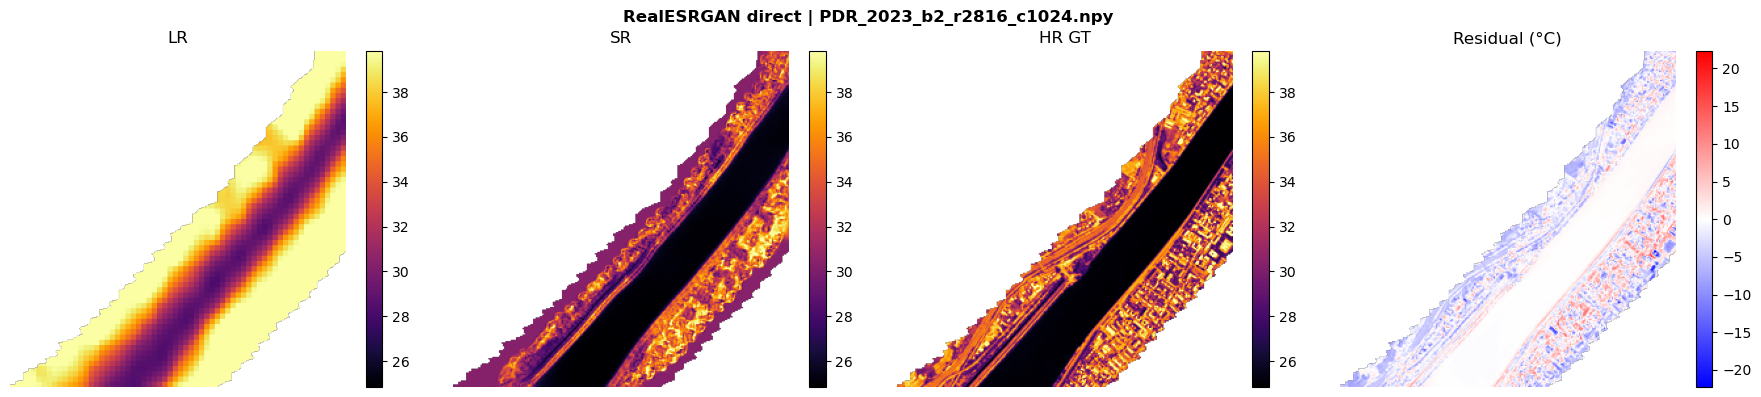

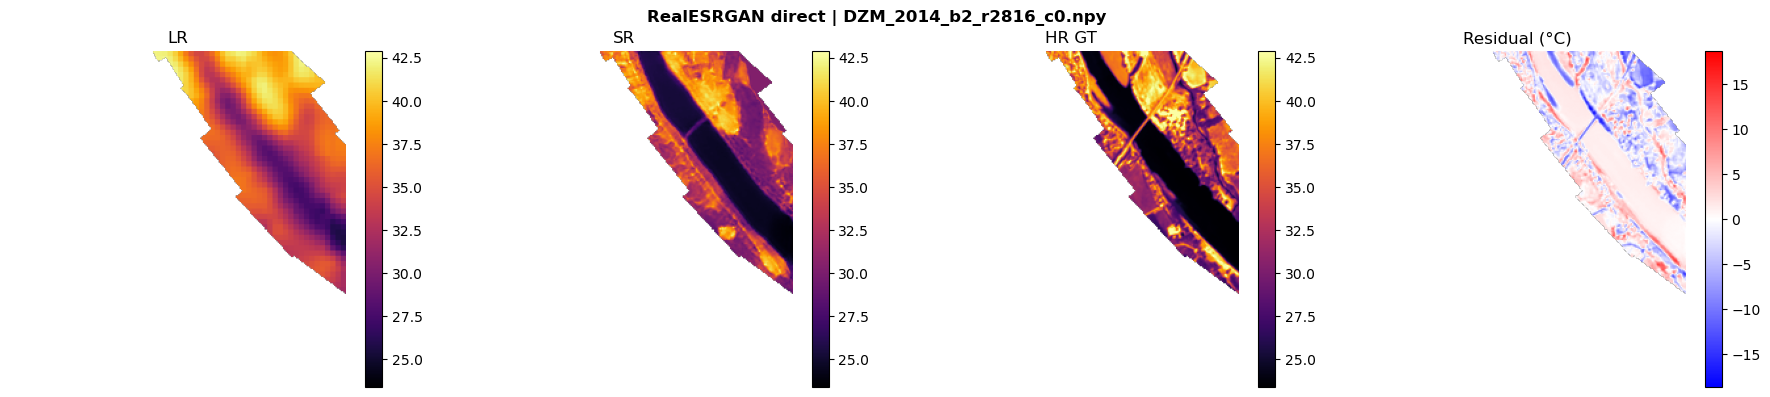

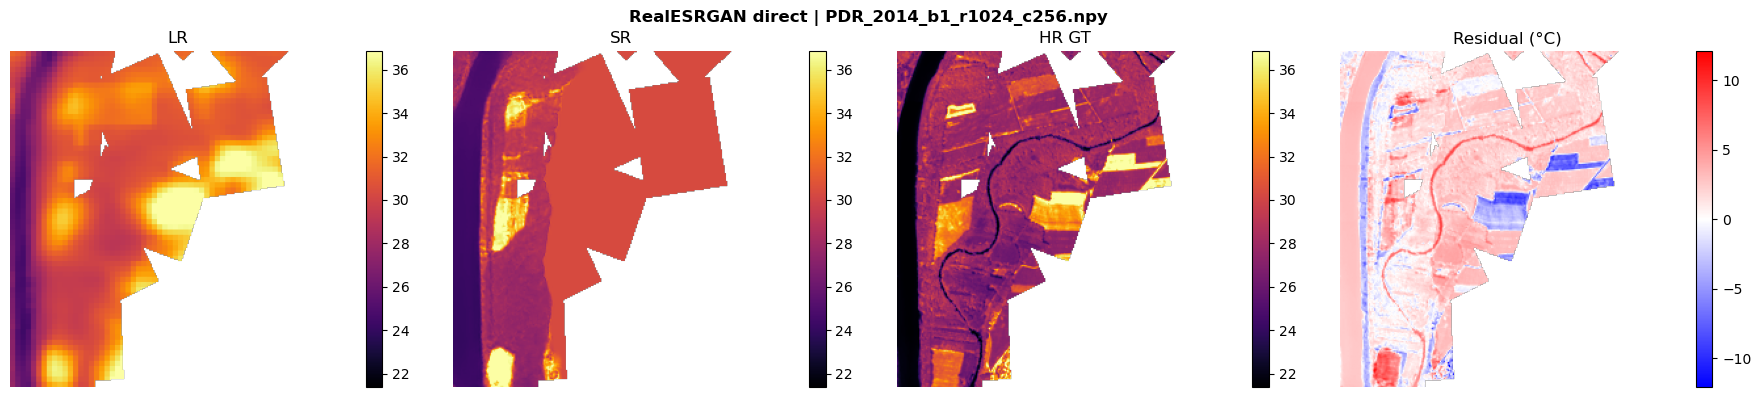

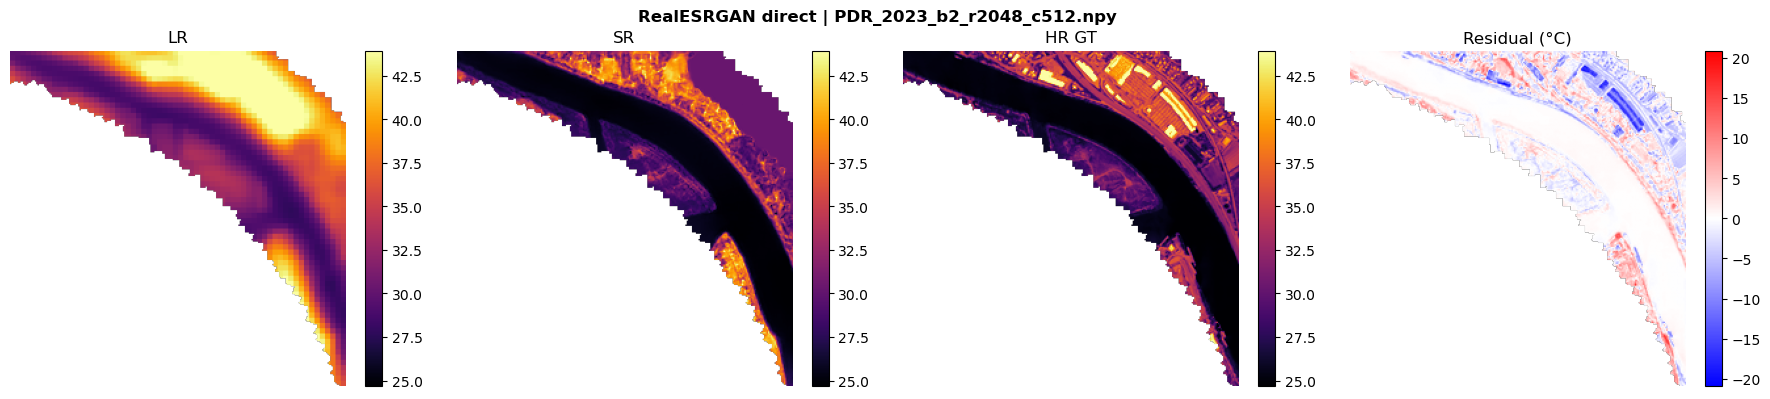

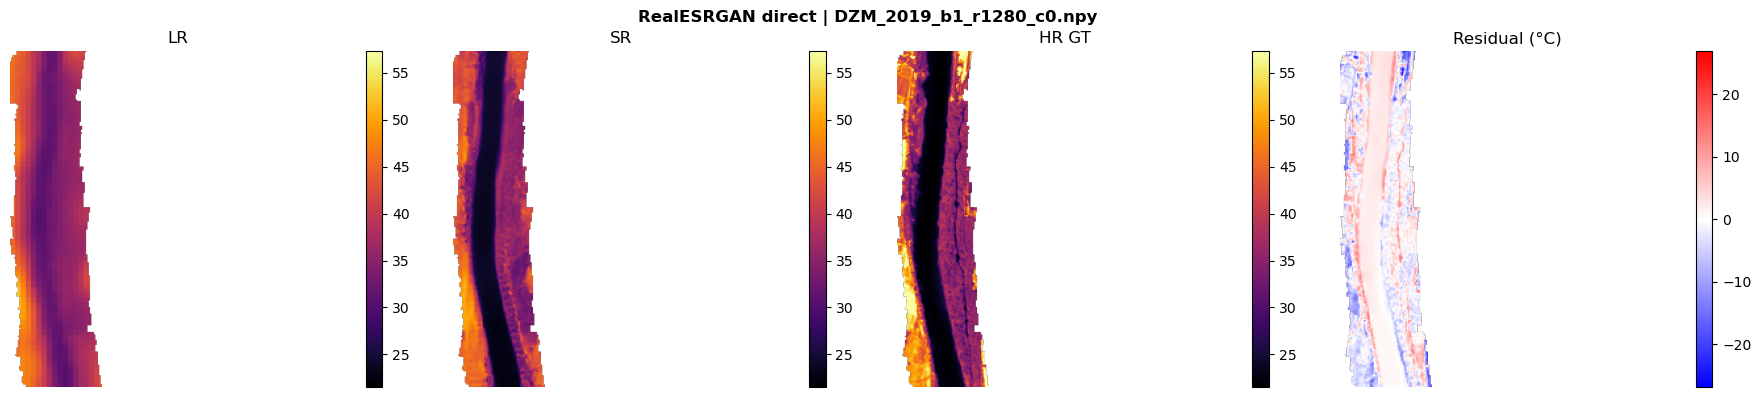

In [8]:
for sample in vis_samples:
    fname = sample["fname"]
    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)
    sr_celsius = run_inference(sample)
    sr_celsius = np.where(hr_mask > 0.5, sr_celsius, np.nan)
    residual   = sr_celsius - hr_np
    res_lim    = (np.nanmax(np.abs(residual)) if np.isfinite(residual).any() else 5)
 
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f"RealESRGAN {ADAPTATION_STRATEGY} | {fname}",
                 fontsize=12, fontweight="bold")
 
    im = axes[0].imshow(lr_np,      cmap="inferno", vmin=vmin, vmax=vmax)
    axes[0].set_title("LR");       axes[0].axis("off"); plt.colorbar(im, ax=axes[0], fraction=0.046)
 
    im = axes[1].imshow(sr_celsius, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[1].set_title("SR");       axes[1].axis("off"); plt.colorbar(im, ax=axes[1], fraction=0.046)
 
    im = axes[2].imshow(hr_np,      cmap="inferno", vmin=vmin, vmax=vmax)
    axes[2].set_title("HR GT");    axes[2].axis("off"); plt.colorbar(im, ax=axes[2], fraction=0.046)
 
    im = axes[3].imshow(residual,   cmap="bwr", vmin=-res_lim, vmax=res_lim)
    axes[3].set_title("Residual (°C)"); axes[3].axis("off"); plt.colorbar(im, ax=axes[3], fraction=0.046)
 
    plt.tight_layout()
    plt.show()
    torch.cuda.empty_cache()



Running inference on full val set (36 samples)...


  36/36 done
Total water pixels: 763,366


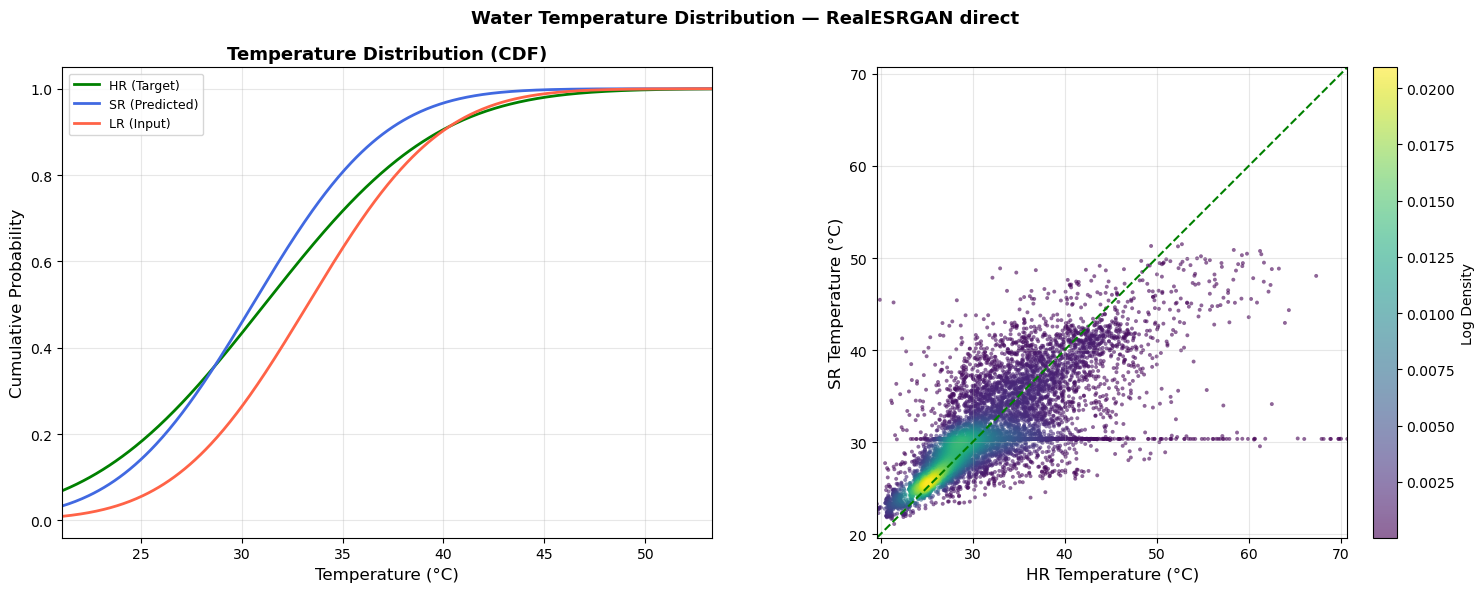

In [10]:
print(f"\nRunning inference on full val set ({len(val_ds)} samples)...")
 
all_hr, all_sr, all_lr = [], [], []
 
for i, sample in enumerate(val_ds):
    hr_mask    = sample["hr_mask"].squeeze().numpy()
    water_mask = sample["water_mask"].squeeze().numpy()
    # valid_mask = (hr_mask > 0.5) & (water_mask > 0.5)   # water pixels only
    valid_mask = hr_mask > 0.5  # all valid pixels (including land)
    if valid_mask.sum() == 0:
        continue
 
    lr_64      = sample["lr"][0].numpy() * LR_STD + LR_MEAN
    lr_256     = np.repeat(np.repeat(lr_64, 4, axis=0), 4, axis=1)
    hr_np      = sample["hr"][0].numpy() * HR_STD + HR_MEAN
    sr_celsius = run_inference(sample)
 
    all_hr.append(hr_np[valid_mask])
    all_sr.append(sr_celsius[valid_mask])
    all_lr.append(lr_256[valid_mask])
 
    if (i + 1) % 50 == 0 or (i + 1) == len(val_ds):
        print(f"  {i + 1}/{len(val_ds)} done")
    torch.cuda.empty_cache()
 
hr_valid = np.concatenate(all_hr)
sr_valid = np.concatenate(all_sr)
lr_valid = np.concatenate(all_lr)
print(f"Total water pixels: {len(hr_valid):,}")
 
vmin = np.percentile(hr_valid, 1)
vmax = np.percentile(hr_valid, 99)
 
palette = {"HR": "green", "SR": "royalblue", "LR": "tomato"}
data    = {"HR": hr_valid, "SR": sr_valid, "LR": lr_valid}
labels  = {"HR": "HR (Target)", "SR": "SR (Predicted)", "LR": "LR (Input)"}
 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Water Temperature Distribution — RealESRGAN {ADAPTATION_STRATEGY}",
             fontsize=13, fontweight="bold")
 
# CDF
ax_cdf = axes[0]
x = np.linspace(vmin, vmax, 500)
for key, vals in data.items():
    mu, std = stats.norm.fit(vals)
    ax_cdf.plot(x, stats.norm.cdf(x, mu, std),
                color=palette[key], lw=2, label=labels[key])
ax_cdf.set_xlim(vmin, vmax)
ax_cdf.set_xlabel("Temperature (°C)", fontsize=12)
ax_cdf.set_ylabel("Cumulative Probability", fontsize=12)
ax_cdf.set_title("Temperature Distribution (CDF)", fontsize=13, fontweight="bold")
ax_cdf.legend(fontsize=9, loc="upper left")
ax_cdf.grid(True, alpha=0.3)
 
# Scatter
ax_scat    = axes[1]
n_pts      = min(len(hr_valid), 10_000)
idx_sample = np.random.choice(len(hr_valid), n_pts, replace=False)
hr_s       = hr_valid[idx_sample]
sr_s       = sr_valid[idx_sample]
t_min      = min(hr_s.min(), sr_s.min())
t_max      = max(hr_s.max(), sr_s.max())
density     = gaussian_kde(np.vstack([hr_s, sr_s]))(np.vstack([hr_s, sr_s]))
log_density = np.log1p(density)
order       = log_density.argsort()
sc = ax_scat.scatter(hr_s[order], sr_s[order],
                     c=log_density[order], cmap="viridis",
                     s=8, alpha=0.6, linewidths=0)
fig.colorbar(sc, ax=ax_scat, label="Log Density", fraction=0.046, pad=0.04)
ax_scat.plot([t_min, t_max], [t_min, t_max], "g--", lw=1.5)
ax_scat.set_xlim(t_min, t_max)
ax_scat.set_ylim(t_min, t_max)
ax_scat.set_aspect("equal")
ax_scat.set_xlabel("HR Temperature (°C)", fontsize=12)
ax_scat.set_ylabel("SR Temperature (°C)", fontsize=12)
ax_scat.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()


### SPADE

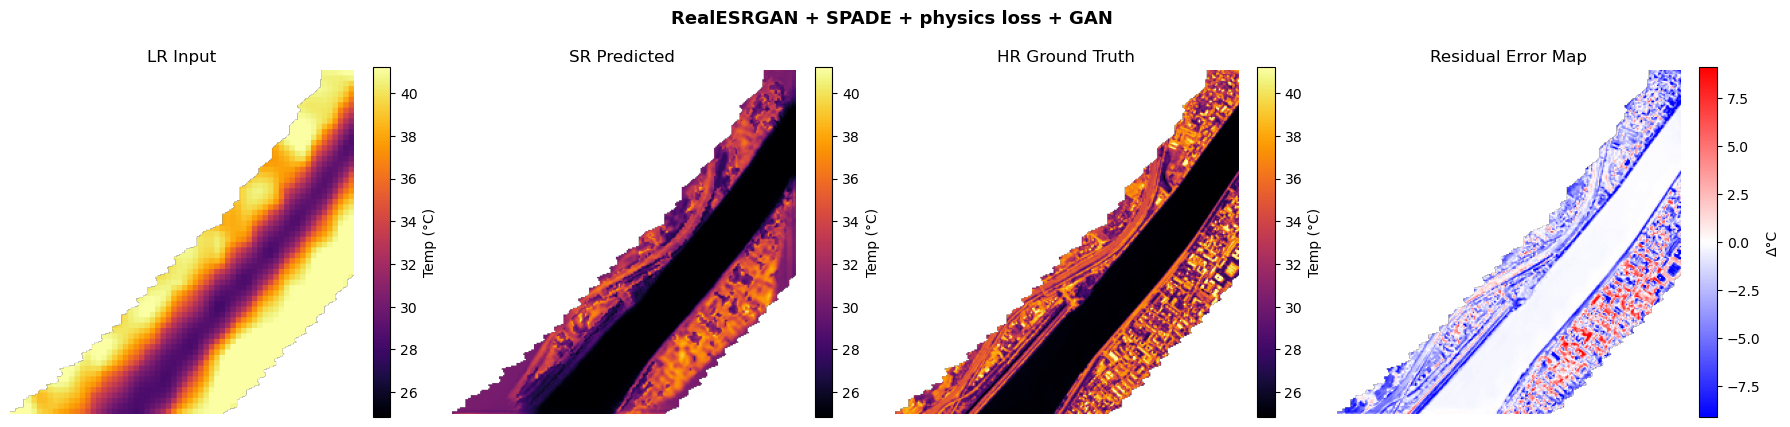

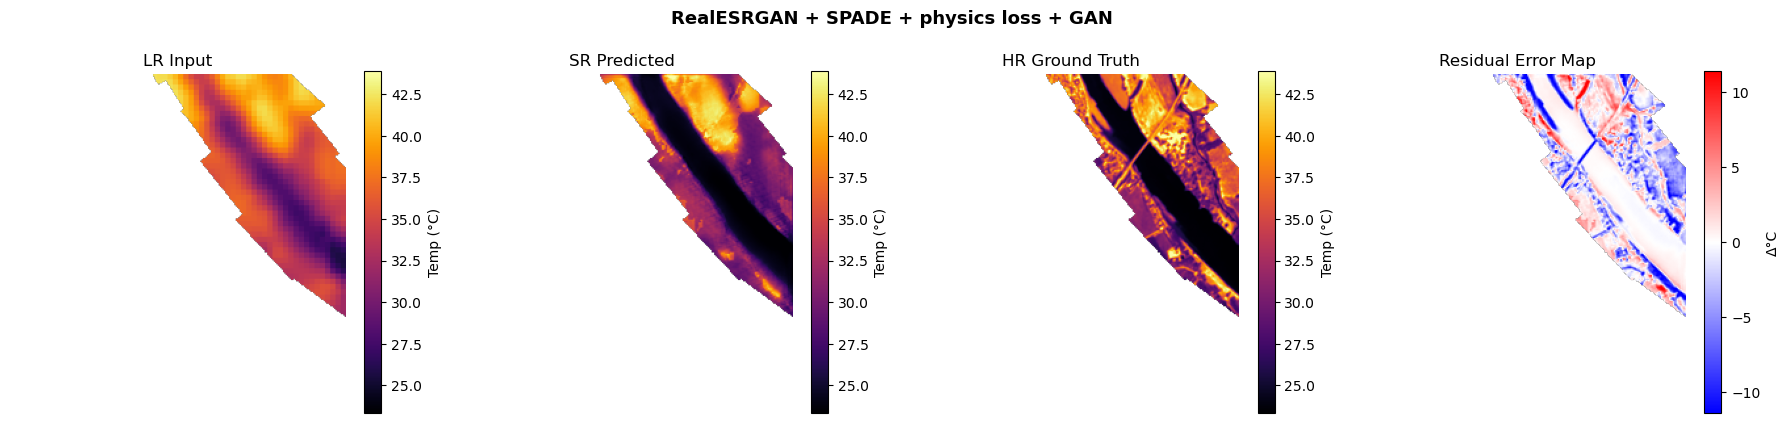

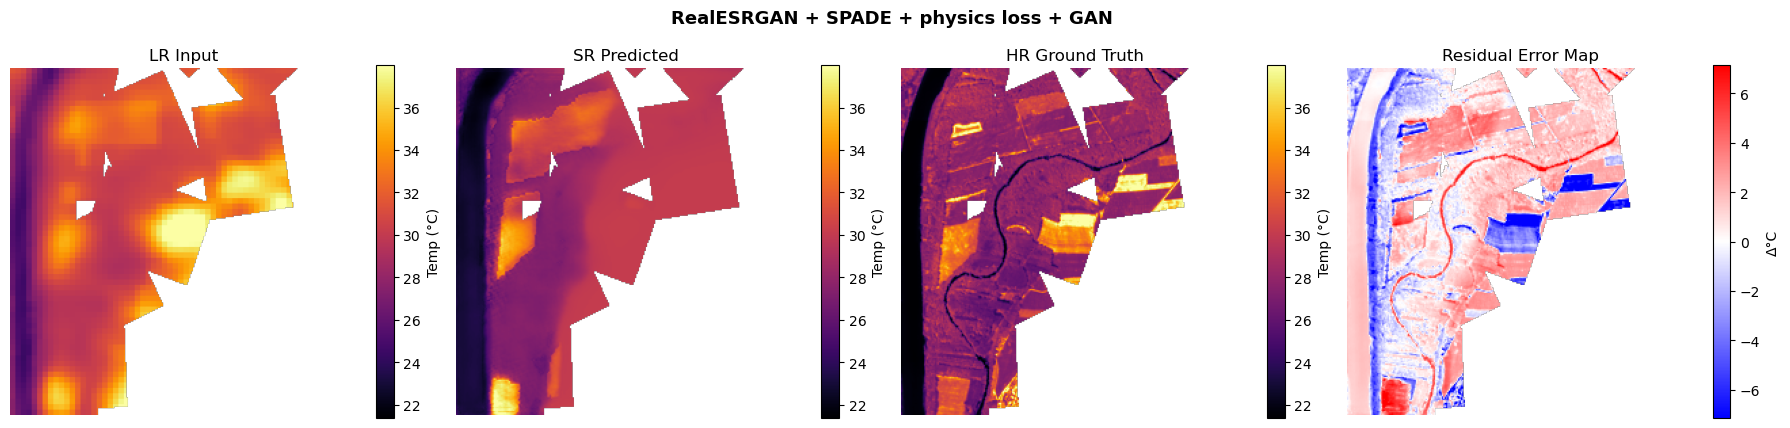

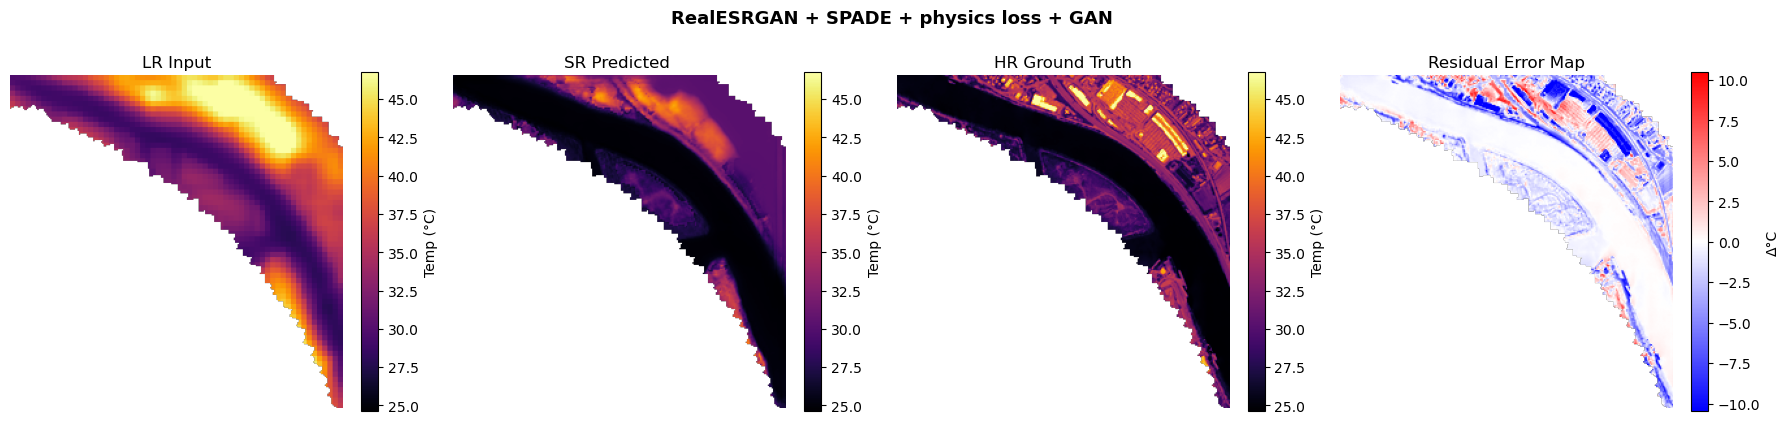

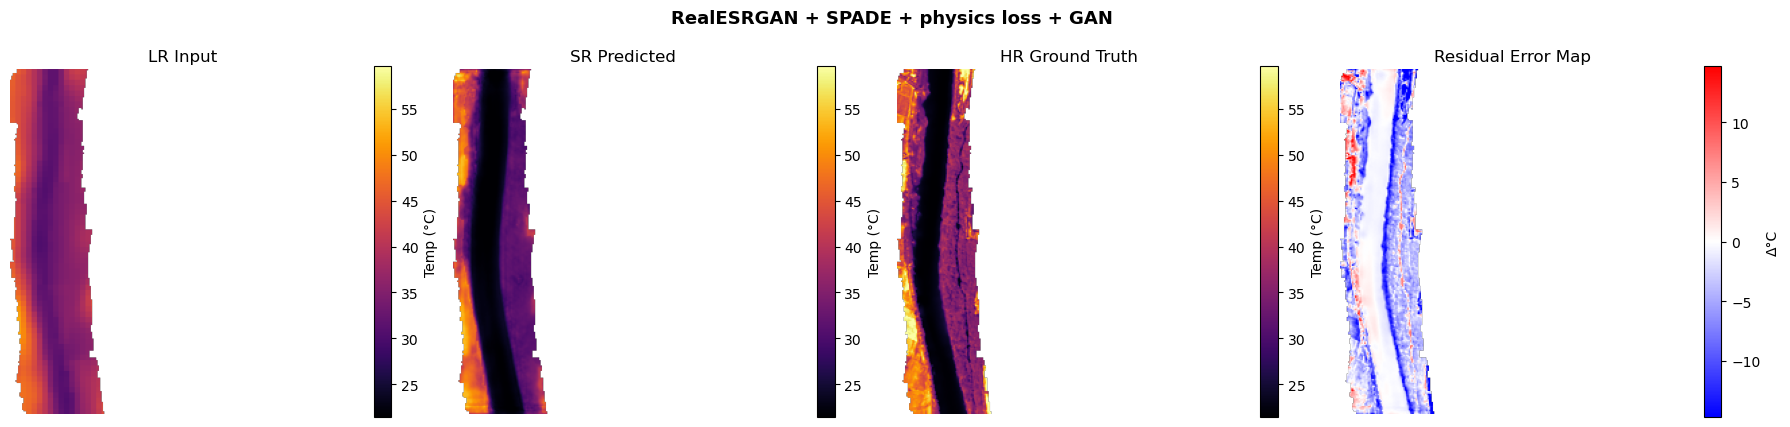

In [8]:
for sample in vis_samples:
    hr_mask = sample["hr_mask"].squeeze().numpy()
    water_mask = sample["water_mask"].squeeze().numpy()
    river_focus = hr_mask > 0.5
    
    # Process spatial arrays (applying spatial grid mask)
    lr_64 = sample["lr"][0].numpy() * LR_STD + LR_MEAN
    lr_256 = np.where(river_focus, np.repeat(np.repeat(lr_64, 4, axis=0), 4, axis=1), np.nan)
    hr_np = np.where(river_focus, sample["hr"][0].numpy() * HR_STD + HR_MEAN, np.nan)
    
    # Predict map values
    sr_np = np.where(river_focus, run_inference(model, sample), np.nan)
    residual = sr_np - hr_np
    
    # ===================================================================
    # CHANGED: Calculate dynamic scale limits using ALL displayed pixels
    # ===================================================================
    displayed_pixels = hr_np[np.isfinite(hr_np)]
    
    # Using 1st and 99th percentiles of the full displayed area expands the 
    # color ceiling to naturally handle hot urban surroundings and mixed pixels.
    vmin = np.percentile(displayed_pixels, 1) if len(displayed_pixels) > 0 else 24.0
    vmax = np.percentile(displayed_pixels, 99) if len(displayed_pixels) > 0 else 28.0
    
    # Isolate valid residuals for a tightly scaled, symmetrical error map
    valid_res = residual[np.isfinite(residual)]
    res_lim = np.percentile(np.abs(valid_res), 98) if len(valid_res) > 0 else 3.0
    # ===================================================================

    # Setup 4-panel visual inspector grid
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    fig.suptitle(f"{MODEL_LABEL} ", 
                 fontsize=13, fontweight="bold")

    # Panel 0: Low-Res Input (Now uses the shared expanded thermal bounds)
    im_lr = axes[0].imshow(lr_256, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[0].set_title("LR Input"); axes[0].axis("off")
    plt.colorbar(im_lr, ax=axes[0], fraction=0.046, label="Temp (°C)") # Added colorbar to see the shift
    
    # Panel 1: Model Prediction
    im_sr = axes[1].imshow(sr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[1].set_title(f"SR Predicted "); axes[1].axis("off")
    plt.colorbar(im_sr, ax=axes[1], fraction=0.046, label="Temp (°C)")
    
    # Panel 2: Ground Truth Target (Urban signatures will now display beautifully)
    im_hr = axes[2].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[2].set_title("HR Ground Truth"); axes[2].axis("off")
    plt.colorbar(im_hr, ax=axes[2], fraction=0.046, label="Temp (°C)") # Added for alignment consistency
    
    # Panel 3: Spatial Residual Errors
    im_res = axes[3].imshow(residual, cmap="bwr", vmin=-res_lim, vmax=res_lim)
    axes[3].set_title("Residual Error Map"); axes[3].axis("off")
    plt.colorbar(im_res, ax=axes[3], fraction=0.046, label="Δ°C")

    plt.tight_layout()
    plt.show()

Extracting physical water-only pixels across full validation stack...


Total pure river water pixels loaded for analysis: 201,515


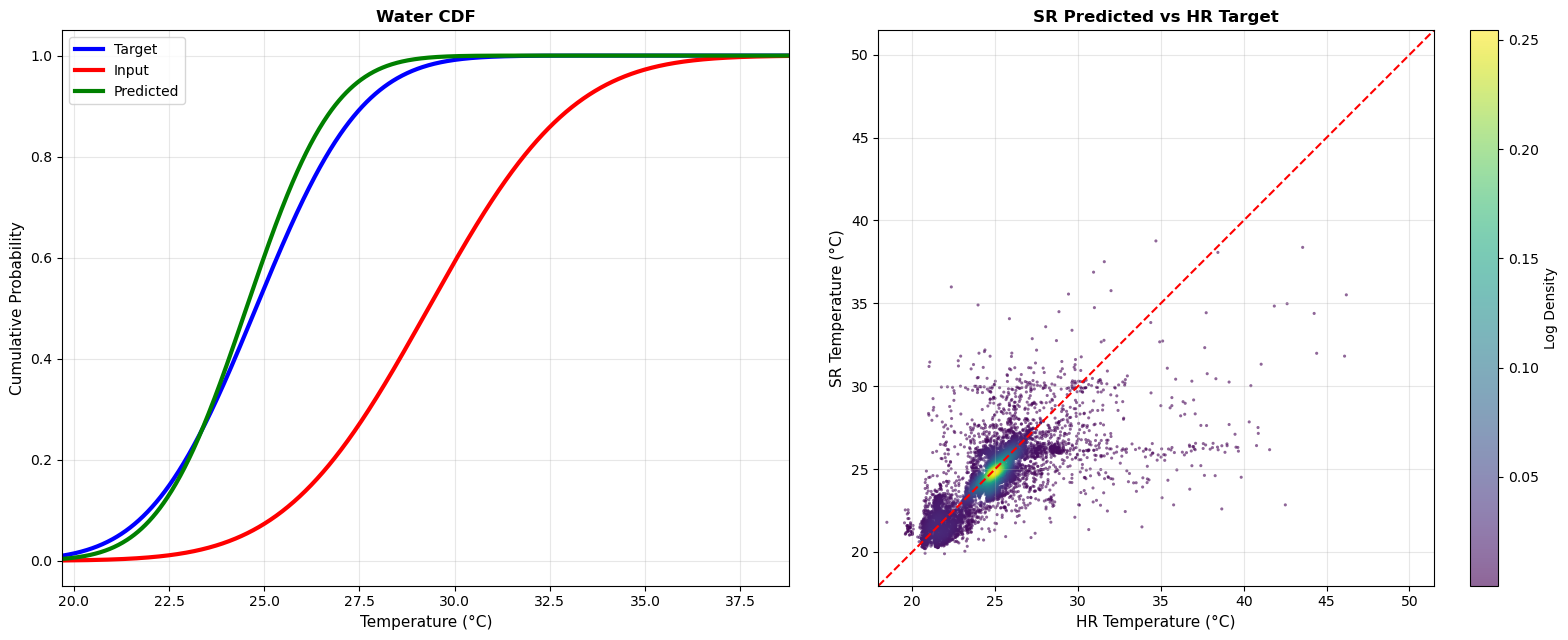

In [9]:
print("Extracting physical water-only pixels across full validation stack...")
all_hr, all_lr, all_sr = [], [], []

for sample in val_ds:
    hr_mask = sample["hr_mask"].squeeze().numpy()
    water_mask = sample["water_mask"].squeeze().numpy()
    
    # CRITICAL: Strict intersection filtering to isolate pure river water
    water_pixels = (hr_mask > 0.5) & (water_mask > 0.5)
    
    if water_pixels.sum() == 0: 
        continue

    # Denormalize arrays to real physical Celsius scales
    hr_np = sample["hr"][0].numpy() * HR_STD + HR_MEAN
    lr_64 = sample["lr"][0].numpy() * LR_STD + LR_MEAN
    lr_256 = np.repeat(np.repeat(lr_64, 4, axis=0), 4, axis=1)

    # Compile water-only arrays
    all_hr.append(hr_np[water_pixels])
    all_lr.append(lr_256[water_pixels])
    all_sr.append(run_inference(model, sample)[water_pixels])

# Flatten arrays across the entire validation dataset space
hr_v, lr_v, sr_v = map(np.concatenate, [all_hr, all_lr, all_sr])
print(f"Total pure river water pixels loaded for analysis: {len(hr_v):,}")

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
palette = {"HR": "blue", "LR": "red", "SR": "green"}

# ------------------- Smooth Gaussian CDF -------------------
ax_cdf = axes[0]

# 1. First, calculate the dynamic bounding limits directly from your validation arrays
padding = 1.0  
xmin = np.percentile(hr_v, 1) - padding
xmax = np.percentile(lr_v, 99) + padding

# 2. Generate the smooth math evaluation axis using those exact dynamic limits
x_axis = np.linspace(xmin, xmax, 1000)

# 3. Fit and plot the perfectly smooth Gaussian curves
for vec, key, lbl in [(hr_v, "HR", "Target"), 
                      (lr_v, "LR", "Input"),
                      (sr_v, "SR", "Predicted")]:
    
    # Fit normal distribution parameters (Mean and Standard Deviation)
    mu, std = stats.norm.fit(vec)
    
    # Calculate the mathematically smooth normal CDF curve over the dynamic range
    gaussian_cdf = stats.norm.cdf(x_axis, mu, std)
    
    ax_cdf.plot(x_axis, gaussian_cdf, color=palette[key], lw=3.0, label=lbl)

# 4. Finalize the panel styling
ax_cdf.set_title("Water CDF", fontsize=12, fontweight="bold")
ax_cdf.set_xlabel("Temperature (°C)", fontsize=11)
ax_cdf.set_ylabel("Cumulative Probability", fontsize=11)
ax_cdf.set_xlim(xmin, xmax) 
ax_cdf.grid(True, alpha=0.3)
ax_cdf.legend(loc="upper left")


# ------------------- 2. Kernel Density Scatter Plot -------------------
ax_scat = axes[1]
idx = np.random.choice(len(hr_v), min(len(hr_v), 12_000), replace=False)
hr_s, sr_s = hr_v[idx], sr_v[idx]

density = gaussian_kde(np.vstack([hr_s, sr_s]))(np.vstack([hr_s, sr_s]))
order = density.argsort()

sc = ax_scat.scatter(
    hr_s[order], sr_s[order], 
    c=np.log1p(density[order]), 
    cmap="viridis", 
    s=5, alpha=0.6, linewidths=0
)

global_min, global_max = min(hr_v.min(), sr_v.min()), max(hr_v.max(), sr_v.max())
ax_scat.plot([global_min, global_max], [global_min, global_max], "r--", lw=1.5)

ax_scat.set_xlim(global_min, global_max)
ax_scat.set_ylim(global_min, global_max)
ax_scat.set_aspect("equal")
ax_scat.set_title("SR Predicted vs HR Target", fontsize=12, fontweight="bold")
ax_scat.set_xlabel("HR Temperature (°C)", fontsize=11)
ax_scat.set_ylabel("SR Temperature (°C)", fontsize=11)
ax_scat.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax_scat, label="Log Density")

plt.tight_layout()
plt.show()